## Imports

In [21]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

RANDOM_SEED = 42

## Generate the Data Matrix and the Label vector

In [2]:
D_list = []
y_list = []

for subject_id in range(1, 41):
    folder = f'data/s{subject_id}'
    for img_id in range(1, 11):
        img_path = os.path.join(folder, f'{img_id}.pgm')
        img = Image.open(img_path)
        img_arr = np.asarray(img).flatten()
        D_list.append(img_arr)
        y_list.append(subject_id)

D = np.array(D_list)
y = np.array(y_list)
print("Data Matrix Shape: ", D.shape)
print("Label Vector Shape: ", y.shape)

Data Matrix Shape:  (400, 10304)
Label Vector Shape:  (400,)


## Split the Dataset into Training and Test sets

In [4]:
"""
From the Data Matrix D400x10304 keep the odd rows for training and the even rows for
testing. This will give you 5 instances per person for training and 5 instances per person
for testing
"""
X_train_lst = []
X_test_lst = []
y_train_lst = []
y_test_lst = []

for row in range(D.shape[0]):
    if row % 2 == 1:
        X_train_lst.append(D[row])
        y_train_lst.append(y[row])
    else:
        X_test_lst.append(D[row])
        y_test_lst.append(y[row])

X_train = np.array(X_train_lst)
X_test = np.array(X_test_lst)
y_train = np.array(y_train_lst)
y_test = np.array(y_test_lst)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(200, 10304)
(200,)
(200, 10304)
(200,)


## PCA Implementation

In [10]:
class PCA:
    def __init__(self, cache_dir=None):
        self.mean = None
        self.eigenvalues = None
        self.eigenvectors = None
        self.explained_variance = None
        self.cumulative_variance = None
        self.cache_dir = cache_dir

        # If a cache path is given, try to load saved eigenvalues/vectors
        if cache_dir:
            try:
                self.eigenvalues = np.load(os.path.join(cache_dir, 'eigenvalues.npy'))
                self.eigenvectors = np.load(os.path.join(cache_dir, 'eigenvectors.npy'))
                self.mean = np.load(os.path.join(cache_dir, 'mean.npy'))
                # Calculate explained variance and cumulative variance
                self.explained_variance = self.eigenvalues / np.sum(self.eigenvalues)
                self.cumulative_variance = np.cumsum(self.explained_variance)
                print("Loaded PCA data from cache.")
            except FileNotFoundError:
                print("PCA cache not found. Will compute and save later.")

    def fit(self, X):
        # Mean-center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Calculate covariance Matrix
        cov_matrix = np.cov(X_centered, rowvar=False)

        # Compute eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Sort the eigenvalues and eigenvectors in descending order
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[sorted_indices]
        self.eigenvectors = eigenvectors[:, sorted_indices]

        # Calculate explained variance and cumulative variance
        self.explained_variance = self.eigenvalues / np.sum(self.eigenvalues)
        self.cumulative_variance = np.cumsum(self.explained_variance)

        # Save to cache if specified
        if self.cache_dir:
            # Ensure the directory exists
            os.makedirs(self.cache_dir, exist_ok=True)
            np.save(os.path.join(self.cache_dir, 'eigenvalues.npy'), self.eigenvalues)
            np.save(os.path.join(self.cache_dir, 'eigenvectors.npy'), self.eigenvectors)
            np.save(os.path.join(self.cache_dir, 'mean.npy'), self.mean)
    
    def transform(self, X, threshold): 
        if self.eigenvectors is None:
            raise Exception("Must call fit() before transform().")
        
        n_components = np.argmax(self.cumulative_variance >= threshold) + 1
        pcs = self.eigenvectors[:, :n_components]
        X_centered = X - self.mean
        return np.dot(X_centered, pcs), n_components
    
    def inverse_transform(self, X_pca, n_components):
        if self.eigenvectors is None:
            raise Exception("Must call fit() before inverse_transform().")
        pcs = self.eigenvectors[:, :n_components]
        return np.dot(X_pca, pcs.T) + self.mean 


In [11]:
# Project the dataset into the reduced PCA subspace and report dimensionality for different thresholds
pca = PCA(cache_dir="pca_results")
pca.fit(X_train)
for alpha in [0.8, 0.85, 0.9, 0.95]:
    X_train_pca, n_components = pca.transform(X_train, alpha)
    print(f"at Alpha = {alpha}, Components Retained (Dimensionality) = {n_components}")

PCA cache not found. Will compute and save later.
at Alpha = 0.8, Components Retained (Dimensionality) = 37
at Alpha = 0.85, Components Retained (Dimensionality) = 53
at Alpha = 0.9, Components Retained (Dimensionality) = 77
at Alpha = 0.95, Components Retained (Dimensionality) = 116


In [22]:
def visualize_faces(X_train, pca, n_faces = 5, pca_threshold=0.9):
    # Randomly choose n_faces indices from the training data
    np.random.seed(RANDOM_SEED)
    indices = np.random.choice(X_train.shape[0], size=n_faces, replace=False)
    sampled_faces = X_train[indices]

    sampled_faces_pca, n_components = pca.transform(sampled_faces, pca_threshold)

    # Approximately reconstruct the faces back to the original space
    reconstructed_faces = pca.inverse_transform(sampled_faces_pca, n_components)

    # Plot the reconstructed faces
    fig, axes = plt.subplots(1, n_faces, figsize=(15, 5))

    for i, face in enumerate(reconstructed_faces):
        axes[i].imshow(face.reshape(112, 92), cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f"Sample {indices[i]}")
    plt.show()

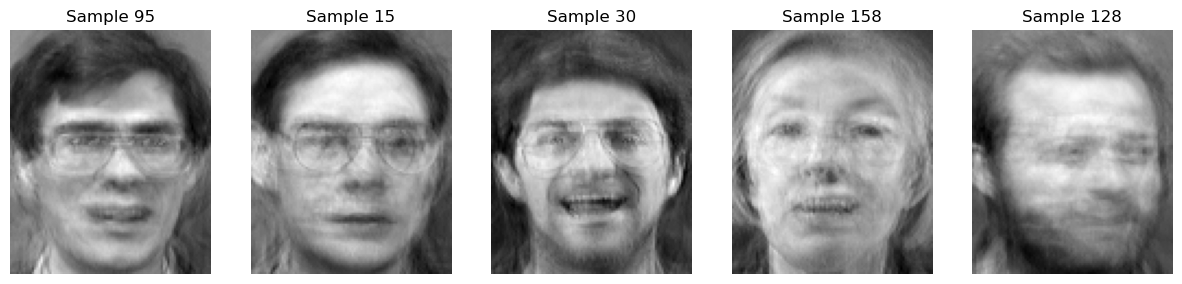

In [24]:
visualize_faces(X_train, pca, n_faces=5, pca_threshold=0.85)